In [ ]:
import importlib, GallenModel_v1, metrics, train
importlib.reload(GallenModel_v1)
importlib.reload(metrics)
importlib.reload(train)
import tensorflow as tf
from tensorflow.keras.models import load_model
from data import dataframe_to_dataset, preprocessing
from sklearn.model_selection import train_test_split
import geopandas as gpd
from data import NormalizationLayer
from metrics import plot_distribution, plot_susceptibility_map, plot_landslide_distribution
from GallenModel_v1 import  NewmarkActivation, DisplacementLayer, LandslideActivationLayer, CohesionLayer, InternalFrictionLayer, ClipLayer

# HOW TO RUN MODEL
* Load model
* Prepare Dataset
* Preprocess data



In [4]:
model = load_model("/Users/giogonzales/Documents/ml-prep/ML-PREP-2025/learn/trainedWeights/trainedCotabatoPhase7/historical/v4-2-2-fos/fold-1-model-0.keras", custom_objects={
    "tf":tf,
    "ClipLayer":ClipLayer
}, safe_mode=False)

In [5]:
df = gpd.read_file('~/Documents/ml-prep/ML-PREP-2025/learn/data/SU_15_Validation1.gpkg')

In [6]:
df, columns, numeric_cols = preprocessing(df, ['landslide_probability', 'landslide_preds', 'confusion', 'sus_pinn_landslide', 'sus_pinn_ground truth', 'ds', 'cohesion', 'internal_friction'])
df, columns, numeric_cols

(            DN     BD_mean   Clay_mean   Sand_mean   Silt_mean  NDVI_mean  \
 0       260790   92.500000  391.000000  297.000000  311.500000   0.736663   
 1       258113   92.242665  391.176284  298.942952  310.150950   0.752155   
 2       260623   92.000000  393.437924  294.584463  312.247812   0.773809   
 3       259982   92.000000  394.000000  297.000000  309.000000   0.783758   
 4       258881   92.933318  383.133364  293.333410  323.599907   0.791762   
 ...        ...         ...         ...         ...         ...        ...   
 241057  359271  122.000000  363.373509  334.599835  301.785990   0.567125   
 241058  359194  123.693475  354.818482  335.441132  310.232286   0.793491   
 241059  359382  120.000000  367.000000  342.000000  291.000000   0.656603   
 241060  359306  122.000000  356.449362  329.739234  314.101276   0.624058   
 241061  359150  122.000000  355.000000  328.000000  317.000000   0.599981   
 
         Est_mean  Nrt_mean  HorCurv_mean  VertCurv_mean  ... 

In [7]:
dataset = dataframe_to_dataset(df[columns], shuffle=False)
susceptibility_prediction = model.predict(dataset)

7534/7534 ━━━━━━━━━━━━━━━━━━━━ 5s 587us/step


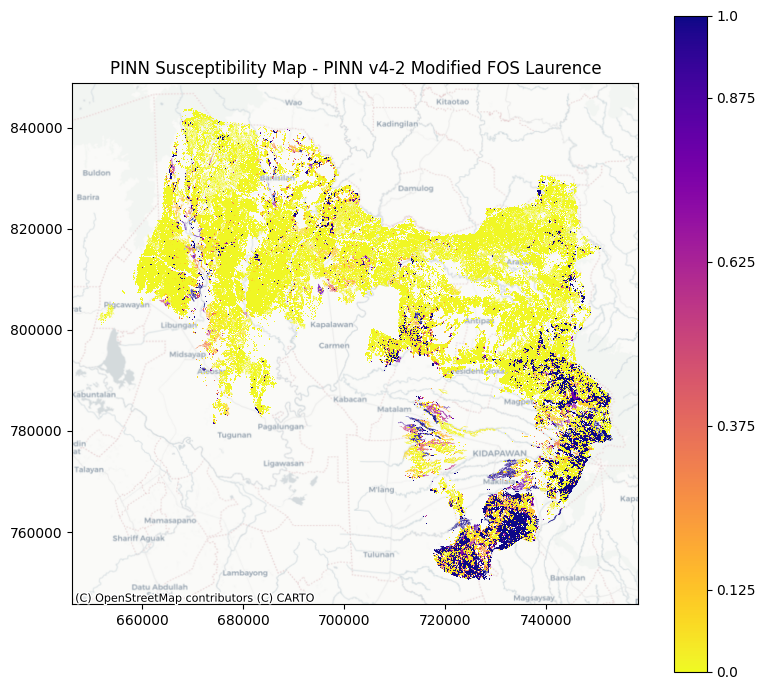

In [8]:
plot_susceptibility_map(df, susceptibility_prediction, "PINN v4-2 Modified FOS Laurence")